In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# 1 - Abrir o arquivo
path = r"h:\3etapa_Py\aula4\CD2022_Populacao_2010_Compatibilizada_20231222 (1).xlsx"

bruto = pd.read_excel(path, header=None)
bruto.head(5)

,0,1,2,3,4,5,6,7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Censo Demográfico 2022: População e Domicílios...,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
3,NaN,RO,11,00015,Alta Floresta D'Oeste,24392,24392,21494
4,NaN,RO,11,00023,Ariquemes,90353,90353,96833


In [19]:
# 2 - Limpar: linha 2 é o cabeçalho, dados começam na linha 3
df = bruto.iloc[2:].copy()
df.columns = bruto.iloc[2]
df = df.iloc[1:].reset_index(drop=True)

# Remover coluna vazia (coluna 0)
df = df.dropna(axis=1, how="all")

# Renomear colunas para facilitar
df.columns = ["UF", "COD. UF", "COD. MUNIC", "NOME DO MUNICÍPIO", "pop_2010_sinopse", "pop_2010", "pop_2022"]

# Garantir que as colunas numéricas são números
for col in ["pop_2010", "pop_2022"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,pop_2010_sinopse,pop_2010,pop_2022
0,RO,11,00015,Alta Floresta D'Oeste,24392,24392.0,21494.0
1,RO,11,00023,Ariquemes,90353,90353.0,96833.0
2,RO,11,00031,Cabixi,6313,6313.0,5351.0
3,RO,11,00049,Cacoal,78574,78574.0,86887.0
4,RO,11,00056,Cerejeiras,17029,17029.0,15890.0


In [20]:
# 3 - Explorar o DataFrame
print(df.shape)
df.dtypes

(5574, 7)


UF                       str
COD. UF               object
COD. MUNIC               str
NOME DO MUNICÍPIO        str
pop_2010_sinopse      object
pop_2010             float64
pop_2022             float64
dtype: object

In [21]:
# 4 - Estatísticas básicas
df[["pop_2010", "pop_2022"]].describe().round(0)

,pop_2010,pop_2022
count,5570.0,5570.0
mean,34247.0,36460.0
std,203038.0,206519.0
min,805.0,833.0
25%,5236.0,5228.0
50%,10896.0,11065.0
75%,23413.0,24427.0
max,11253503.0,11451999.0


## Agrupando por Estado (UF)

In [22]:
# 5 - GROUP BY: população total por estado
pop_estado = (
    df.groupby(["COD. UF", "UF"], as_index=False)
      .agg(
          pop_2010=("pop_2010", "sum"),
          pop_2022=("pop_2022", "sum"),
      )
)

# Calcular crescimento absoluto e percentual
pop_estado["crescimento"] = pop_estado["pop_2022"] - pop_estado["pop_2010"]
pop_estado["crescimento_pct"] = (pop_estado["crescimento"] / pop_estado["pop_2010"] * 100).round(2)

pop_estado = pop_estado.sort_values("crescimento", ascending=False).reset_index(drop=True)
pop_estado

,COD. UF,UF,pop_2010,pop_2022,crescimento,crescimento_pct
0,35,SP,41262199.0,44411238.0,3149039.0,7.63
1,42,SC,6248436.0,7610361.0,1361925.0,21.80
2,52,GO,6001789.0,7056495.0,1054706.0,17.57
3,41,PR,10444526.0,11444380.0,999854.0,9.57
4,31,MG,19597330.0,20539989.0,942659.0,4.81
5,51,MT,3035122.0,3658649.0,623527.0,20.54
6,15,PA,7581051.0,8120131.0,539080.0,7.11
7,13,AM,3483985.0,3941613.0,457628.0,13.14
8,23,CE,8451644.0,8794957.0,343313.0,4.06
9,32,ES,3514952.0,3833712.0,318760.0,9.07


In [23]:
# 6 - Salvar tabela por estado em CSV
pop_estado.to_csv(r"h:\3etapa_Py\aula4\populacao_por_estado.csv", sep=";", index=False)
print("Salvo!")

Salvo!


## Agrupando por Município

In [24]:

pop_municipio = df[["UF", "COD. UF", "COD. MUNIC", "NOME DO MUNICÍPIO", "pop_2010", "pop_2022"]].copy()

pop_municipio["crescimento"] = pop_municipio["pop_2022"] - pop_municipio["pop_2010"]
pop_municipio["crescimento_pct"] = (pop_municipio["crescimento"] / pop_municipio["pop_2010"] * 100).round(2)


pop_municipio = pop_municipio.sort_values("crescimento", ascending=False).reset_index(drop=True)
pop_municipio.head(10)

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,pop_2010,pop_2022,crescimento,crescimento_pct
0,AM,13,02603,Manaus,1802014.0,2063689.0,261675.0,14.52
1,DF,53,00108,Brasília,2572159.0,2817381.0,245222.0,9.53
2,SP,35,50308,São Paulo,11253503.0,11451999.0,198496.0,1.76
3,SP,35,52205,Sorocaba,586816.0,723682.0,136866.0,23.32
4,GO,52,08707,Goiânia,1301912.0,1437366.0,135454.0,10.40
5,RR,14,00100,Boa Vista,284313.0,413486.0,129173.0,45.43
6,SC,42,05407,Florianópolis,421240.0,537211.0,115971.0,27.53
7,PA,15,05536,Parauapebas,153908.0,267836.0,113928.0,74.02
8,MS,50,02704,Campo Grande,786774.0,898100.0,111326.0,14.15
9,PB,25,07507,João Pessoa,723515.0,833932.0,110417.0,15.26


In [25]:

pop_municipio.to_csv(r"h:\3etapa_Py\aula4\populacao_por_municipio.csv", sep=";", index=False)
print("Salvo!")

Salvo!


## Gráficos

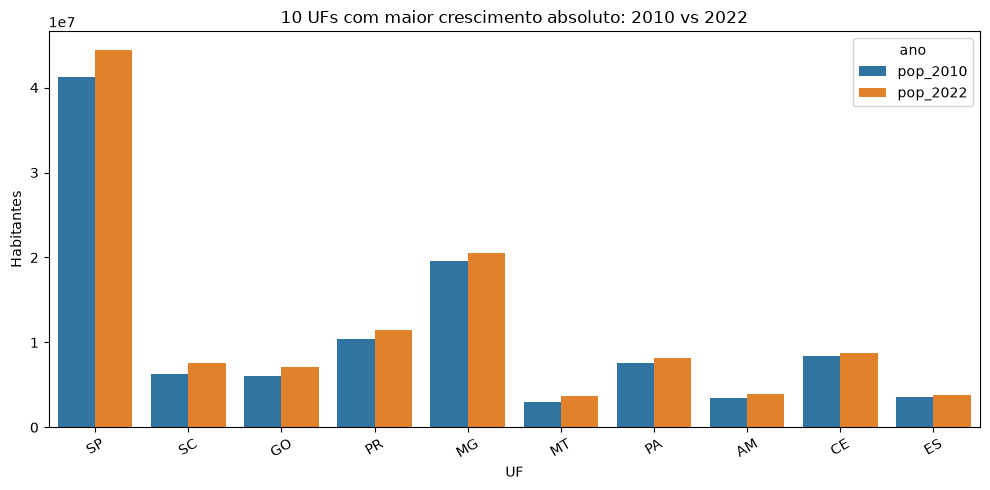

In [26]:

top = pop_estado.head(10).melt(
    id_vars="UF",
    value_vars=["pop_2010", "pop_2022"],
    var_name="ano",
    value_name="populacao",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="UF", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

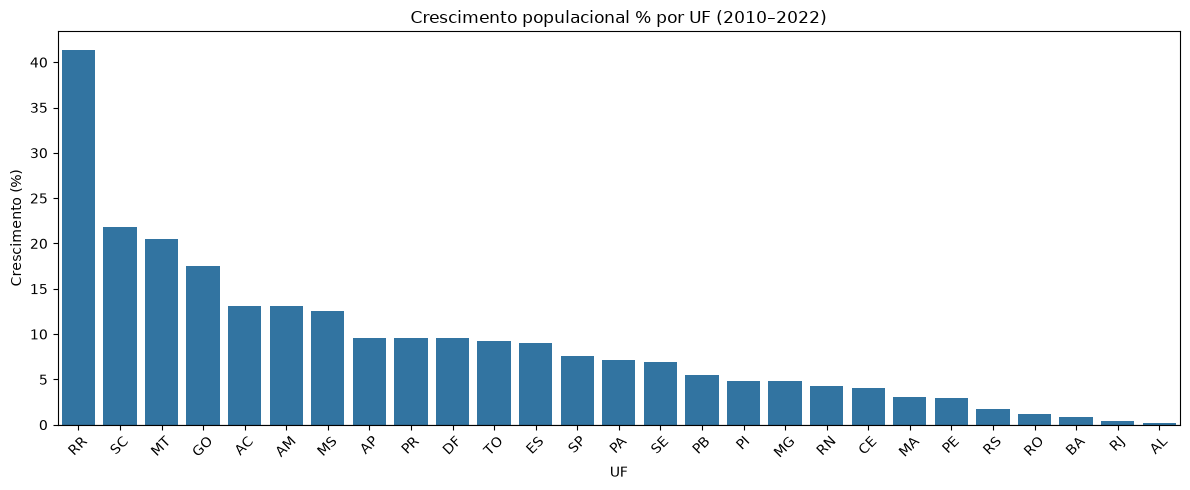

In [27]:

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=pop_estado.sort_values("crescimento_pct", ascending=False),
    x="UF", y="crescimento_pct", ax=ax
)
ax.set_title("Crescimento populacional % por UF (2010–2022)")
ax.set_ylabel("Crescimento (%)")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

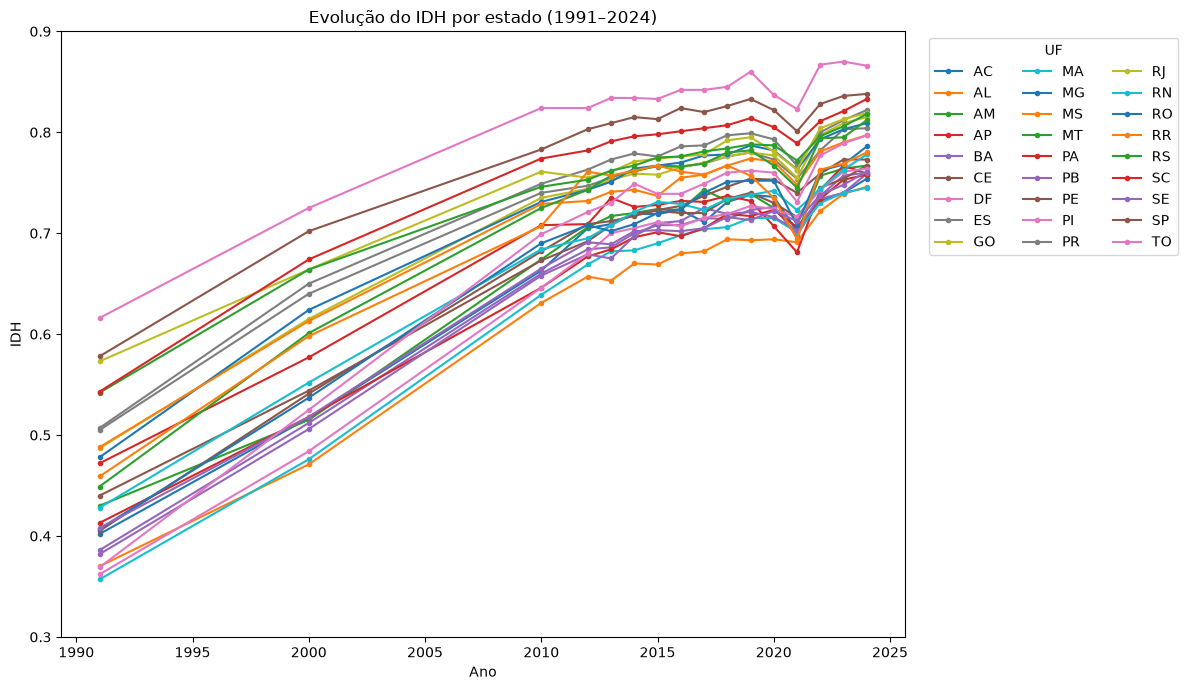

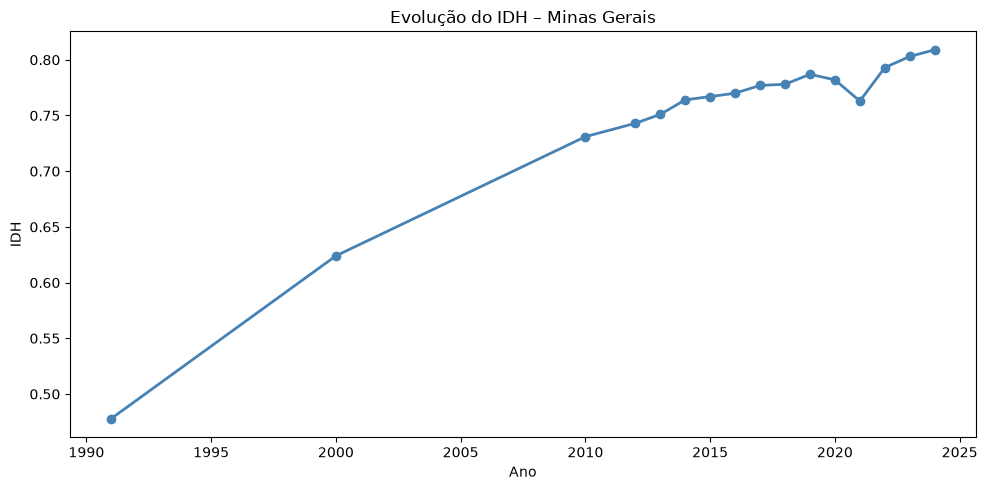

In [30]:
df = pd.read_csv(
    r"h:\3etapa_Py\aula4\Tabela4.csv",
    sep=";",
    decimal=",",
    skiprows=1,       
    encoding="latin1"
)


df = df.dropna(axis=1, how="all")

anos = [c for c in df.columns if str(c).isdigit()]
variaveis = [c for c in df.columns if c not in anos]

df_longo = df.melt(
    id_vars=variaveis,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
df_longo["Ano"] = df_longo["Ano"].astype(int)

fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()


mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mg["Ano"], mg["IDH"], marker="o", color="steelblue", linewidth=2)
ax.set_title("Evolução do IDH – Minas Gerais")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
fig.tight_layout()
plt.show()

